# CatBoost Workspace

Отдельный ноутбук только для CatBoost.

Здесь используется изолированный модуль `model_baselines_catboost.py`, чтобы не тянуть Naive, ARIMA, SARIMA, N-BEATS и LSTM.

Поток работы:
1. загрузка и очистка данных,
2. настройка CatBoost и профиля поиска,
3. `HalvingGridSearchCV` + финальное обучение,
4. rolling 24h benchmark на minute-данных,
5. экспорт результатов.

## 1) Окружение

При необходимости раскомментируй установку пакетов и перезапусти kernel.

In [1]:
# %pip install pandas numpy requests statsmodels matplotlib seaborn scikit-learn torch tqdm catboost

import sys
print('Python:', sys.version)

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


## 2) Импорты и базовая конфигурация

Подключаем проект, включаем изолированный CatBoost-модуль и задаём общие параметры запуска.

In [ ]:
import importlib



import os



from pathlib import Path



import pandas as pd



import seaborn as sns



import torch



from data_pipeline import (

    DataConfig,

    DataProcessor,

    build_datasets,

    load_klines_from_sqlite,

    load_market_snapshots_from_sqlite,

    sync_market_data_to_sqlite,

)



import model_baselines_catboost as _mb



from export_utils import plot_result



_mb = importlib.reload(_mb)



run_catboost = _mb.run_catboost



run_catboost_gridsearchcv_native_pipeline = _mb.run_catboost_gridsearchcv_native_pipeline



fit_catboost_inference_model = _mb.fit_catboost_inference_model



predict_catboost_inference = _mb.predict_catboost_inference



CPU_COUNT = int(os.cpu_count() or 8)



SAFE_CPU_WORKERS = max(1, min(16, CPU_COUNT - 1))



pd.set_option('display.max_columns', 50)



pd.set_option('display.width', 160)



sns.set_theme(style='whitegrid')



CONFIG = DataConfig(

    base_url='https://api.bybit.com',

    interval='1',

    bars=100_000,

    target_col='close',

    date_col='timestamp',

    test_ratio=0.2,

)



SYMBOLS = ['BTCUSDT', 'ETHUSDT']



OUTPUT_DIR = Path('data/outputs')



OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



SQLITE_DB_PATH = Path('data/market_data.sqlite')



MARKET_SNAPSHOT_ROWS = 5



print('CatBoost module file:', Path(_mb.__file__).resolve())



print('SQLite DB:', SQLITE_DB_PATH.resolve())



print('CUDA available:', torch.cuda.is_available())



if torch.cuda.is_available():

    print('GPU:', torch.cuda.get_device_name(0))



print('SAFE_CPU_WORKERS:', SAFE_CPU_WORKERS)



print(f'Data config: interval={CONFIG.interval}m | bars={CONFIG.bars:,}')

CatBoost module file: C:\Users\zzz20\ModelLine\model_baselines_catboost.py
CUDA available: True
GPU: NVIDIA GeForce RTX 4080
SAFE_CPU_WORKERS: 16
Data config: interval=60 | bars=30,000


## 3) Загрузка, очистка и разбиение данных

Скачиваем или читаем локальные ряды, затем очищаем и строим `full/train/test`.

In [ ]:
raw_data = {}

processor = DataProcessor(target_col=CONFIG.target_col, date_col=CONFIG.date_col)

cleaned_data = {}

reports = {}

latest_snapshot_rows = []



for symbol in SYMBOLS:

    try:

        synced_df, snapshot = sync_market_data_to_sqlite(

            symbol=symbol,

            config=CONFIG,

            db_path=SQLITE_DB_PATH,

            history_bars=CONFIG.bars,

            fetch_snapshot=True,

        )

        raw_data[symbol] = load_klines_from_sqlite(

            symbol=symbol,

            interval=CONFIG.interval,

            db_path=SQLITE_DB_PATH,

            limit=CONFIG.bars,

        )

        print(

            f'{symbol}: SQLite sync complete | history_rows={len(raw_data[symbol])} | '

            f'snapshot_ts={snapshot["snapshot_ts"] if snapshot is not None else "n/a"}'

        )

    except Exception as ex:

        cached_df = load_klines_from_sqlite(

            symbol=symbol,

            interval=CONFIG.interval,

            db_path=SQLITE_DB_PATH,

            limit=CONFIG.bars,

        )

        if len(cached_df) == 0:

            raise RuntimeError(

                f'{symbol}: не удалось синхронизировать данные в SQLite и в базе нет кэша. Ошибка: {ex}'

            )

        raw_data[symbol] = cached_df

        print(f'{symbol}: sync error ({ex}), использован SQLite cache rows={len(cached_df)}')



    snapshot_df = load_market_snapshots_from_sqlite(symbol=symbol, db_path=SQLITE_DB_PATH, limit=1)

    if len(snapshot_df) > 0:

        latest_snapshot_rows.append(snapshot_df.iloc[0].to_dict())



for symbol, df in raw_data.items():

    clean_df, rep = processor.process(df)

    cleaned_data[symbol] = clean_df

    reports[symbol] = rep

    print(

        f'{symbol}: before={rep["initial_rows"]} after={rep["final_rows"]} removed={rep["removed_total"]} '

        f'(zero/nonpos={rep["removed_nonpositive_or_zero"]}, outliers={rep["removed_outliers"]})'

    )



datasets = build_datasets(cleaned_data, target_col=CONFIG.target_col, test_ratio=CONFIG.test_ratio)

for symbol, data in datasets.items():

    print(f'{symbol}: full={len(data["full"])} train={len(data["train"])} test={len(data["test"])}')



LATEST_SNAPSHOT_DF = pd.DataFrame(latest_snapshot_rows)

if len(LATEST_SNAPSHOT_DF) > 0:

    LATEST_SNAPSHOT_DF['snapshot_ts'] = pd.to_datetime(LATEST_SNAPSHOT_DF['snapshot_ts'], utc=True)

    print('\nТекущий рынок из SQLite snapshot:')

    display(LATEST_SNAPSHOT_DF[['symbol', 'snapshot_ts', 'last_price', 'bid_price', 'ask_price', 'bid_size', 'ask_size', 'spread']])



cleaned_data['BTCUSDT'].head()

BTCUSDT: 30000 rows (скачано с API, сохранено в data\btcusdt_timeseries.csv)
ETHUSDT: 30000 rows (скачано с API, сохранено в data\ethusdt_timeseries.csv)
BTCUSDT: before=30000 after=29839 removed=161 (zero/nonpos=0, outliers=161)
ETHUSDT: before=30000 after=29851 removed=149 (zero/nonpos=0, outliers=149)
BTCUSDT: full=29839 train=23871 test=5968
ETHUSDT: full=29851 train=23880 test=5971


,timestamp,open,high,low,close,volume,turnover
0,2022-10-06 05:00:00+00:00,20344.0,20360.5,20241.0,20292.5,7839.766,1.591436e+08
1,2022-10-06 06:00:00+00:00,20292.5,20292.5,20156.5,20167.5,8319.582,1.682303e+08
2,2022-10-06 07:00:00+00:00,20167.5,20240.0,20139.0,20217.0,5637.972,1.138470e+08
3,2022-10-06 08:00:00+00:00,20217.0,20244.5,20100.0,20137.0,8168.341,1.645964e+08
4,2022-10-06 09:00:00+00:00,20137.0,20174.5,20082.5,20090.5,5235.127,1.054051e+08


## 4) Конфиг эксперимента CatBoost

Здесь меняются символ, профиль поиска, scoring и параметры rolling benchmark.

In [4]:
from sklearn.model_selection import ParameterGrid

RUN_SYMBOL = 'BTCUSDT'
RUN_MODEL = 'catboost'

CATBOOST_GRID_PROFILE = 'balanced'  # quick | balanced | full
CATBOOST_SCORING = 'MAE'
CATBOOST_TIME_WEIGHT = 0.05
CATBOOST_USE_CUDA = bool(torch.cuda.is_available())
CATBOOST_GRID_N_JOBS = 1
CATBOOST_CV_SPLITS = 2
CATBOOST_HALVING_FACTOR = 4
CATBOOST_SEARCH_MIN_POINTS = 512
CATBOOST_SEARCH_MAX_POINTS = 4_096

ROLLING_BENCHMARK_ENABLED = True
BENCHMARK_INTERVAL = '1'
BENCHMARK_TRAIN_MINUTES = 40_000
BENCHMARK_TEST_MINUTES = 24 * 60
BENCHMARK_WINDOWS = 10
BENCHMARK_FETCH_BUFFER = 4_000
BENCHMARK_END_TS = pd.Timestamp.now(tz='UTC').floor('min')
BENCHMARK_FORCE_CPU = False

train = datasets[RUN_SYMBOL]['train']
test = datasets[RUN_SYMBOL]['test']
full = datasets[RUN_SYMBOL]['full']

ALL_RESULTS = {}
TRAINED_MODELS = {}

def _singleton_grid(anchor):
    return {key: [value] for key, value in anchor.items()}

def _non_anchor_values(values, anchor_value):
    return [value for value in values if value != anchor_value]

def _build_catboost_coverage_grid(full_values, anchor):
    blocks = [
        {**_singleton_grid(anchor), 'context_len': _non_anchor_values(full_values['context_len'], anchor['context_len'])},
        {**_singleton_grid(anchor), 'depth': _non_anchor_values(full_values['depth'], anchor['depth'])},
        {**_singleton_grid(anchor), 'learning_rate': _non_anchor_values(full_values['learning_rate'], anchor['learning_rate'])},
        {**_singleton_grid(anchor), 'iterations': _non_anchor_values(full_values['iterations'], anchor['iterations'])},
        {**_singleton_grid(anchor), 'l2_leaf_reg': _non_anchor_values(full_values['l2_leaf_reg'], anchor['l2_leaf_reg'])},
        _singleton_grid(anchor),
    ]
    return [block for block in blocks if all(len(values) > 0 for values in block.values())]

GRID_PROFILES = {
    'quick': {
        'context_len': [72],
        'depth': [6],
        'learning_rate': [0.05],
        'iterations': [160],
        'l2_leaf_reg': [3.0],
        'use_cuda': [CATBOOST_USE_CUDA],
    },
    'balanced': [
        {
            'context_len': [72, 120, 168],
            'depth': [8],
            'learning_rate': [0.04],
            'iterations': [280],
            'l2_leaf_reg': [3.0],
            'use_cuda': [CATBOOST_USE_CUDA],
        },
        {
            'context_len': [120],
            'depth': [6, 8, 10],
            'learning_rate': [0.04],
            'iterations': [280],
            'l2_leaf_reg': [3.0],
            'use_cuda': [CATBOOST_USE_CUDA],
        },
        {
            'context_len': [120],
            'depth': [8],
            'learning_rate': [0.03, 0.04, 0.05],
            'iterations': [160, 280, 420],
            'l2_leaf_reg': [3.0, 5.0],
            'use_cuda': [CATBOOST_USE_CUDA],
        },
    ],
    'full': _build_catboost_coverage_grid(
        full_values={
            'context_len': [72, 120, 168],
            'depth': [6, 8, 10],
            'learning_rate': [0.03, 0.04, 0.05],
            'iterations': [160, 280, 420],
            'l2_leaf_reg': [3.0, 5.0],
        },
        anchor={
            'context_len': 120,
            'depth': 8,
            'learning_rate': 0.04,
            'iterations': 280,
            'l2_leaf_reg': 3.0,
            'use_cuda': CATBOOST_USE_CUDA,
        },
    ),
}

if CATBOOST_GRID_PROFILE not in GRID_PROFILES:
    raise ValueError(f'Unknown CATBOOST_GRID_PROFILE: {CATBOOST_GRID_PROFILE}')

CATBOOST_PARAM_GRID = GRID_PROFILES[CATBOOST_GRID_PROFILE]
CATBOOST_PARAM_GRID_CANDIDATES = len(ParameterGrid(CATBOOST_PARAM_GRID))

print(f'RUN_SYMBOL={RUN_SYMBOL} | full={len(full)} | train={len(train)} | test={len(test)}')
print(f'CatBoost grid profile: {CATBOOST_GRID_PROFILE}')
print('CatBoost device:', torch.cuda.get_device_name(0) if CATBOOST_USE_CUDA else 'cpu')
print(
    f'CatBoost config: use_cuda={CATBOOST_USE_CUDA}, n_jobs={CATBOOST_GRID_N_JOBS}, ' +
    f'cv_splits={CATBOOST_CV_SPLITS}, candidates={CATBOOST_PARAM_GRID_CANDIDATES}'
)
print(
    f'CatBoost search: min_points={CATBOOST_SEARCH_MIN_POINTS}, max_points={CATBOOST_SEARCH_MAX_POINTS}, ' +
    f'factor={CATBOOST_HALVING_FACTOR}, scoring={CATBOOST_SCORING}, time_weight={CATBOOST_TIME_WEIGHT}'
)
CATBOOST_PARAM_GRID

RUN_SYMBOL=BTCUSDT | full=29839 | train=23871 | test=5968
CatBoost grid profile: balanced
CatBoost device: NVIDIA GeForce RTX 4080
CatBoost config: use_cuda=True, n_jobs=1, cv_splits=2, candidates=24
CatBoost search: min_points=512, max_points=4096, factor=4, scoring=MAE, time_weight=0.05


[{'context_len': [72, 120, 168],
  'depth': [8],
  'learning_rate': [0.04],
  'iterations': [280],
  'l2_leaf_reg': [3.0],
  'use_cuda': [True]},
 {'context_len': [120],
  'depth': [6, 8, 10],
  'learning_rate': [0.04],
  'iterations': [280],
  'l2_leaf_reg': [3.0],
  'use_cuda': [True]},
 {'context_len': [120],
  'depth': [8],
  'learning_rate': [0.03, 0.04, 0.05],
  'iterations': [160, 280, 420],
  'l2_leaf_reg': [3.0, 5.0],
  'use_cuda': [True]}]

## 5) Подбор гиперпараметров и финальное обучение

Запускаем `HalvingGridSearchCV`, сохраняем лучшую конфигурацию и обучаем inference-модель CatBoost.

CatBoost HalvingGridSearchCV: train_points=23871 | test_points=5968 | n_splits=2 | min_resources=512 | max_resources=4096 | factor=4 | aggressive_elimination=True | scoring=MAE


CATBOOST HalvingGridSearchCV: 64fit [07:45,  7.27s/fit]                       


CatBoost HalvingGridSearchCV: best MAE=237.575586 | {'context_len': 120, 'depth': 8, 'iterations': 160, 'l2_leaf_reg': 5.0, 'learning_rate': 0.03, 'use_cuda': True}
CatBoost final fit: train_points=2048 (best halving resource window) | test_points=5968
CatBoost device: GPU
CatBoost split info: {'full_points': 29839, 'train_points': 23871, 'test_points': 5968, 'test_ratio': 0.2, 'cv_n_splits': 2, 'min_resource_points': 512, 'max_resource_points': 4096, 'best_resource_points': 2048, 'halving_factor': 4, 'aggressive_elimination': True, 'time_weight': 0.05}
CatBoost best params: {'context_len': 120, 'depth': 8, 'iterations': 160, 'l2_leaf_reg': 5.0, 'learning_rate': 0.03, 'use_cuda': True}
CatBoost metrics: {'MAE': 289.83221637716554, 'RMSE': 434.9736418092219, 'MAPE': 0.30273246876270415}


,score,score_std,param_context_len,param_depth,param_learning_rate,param_iterations,param_l2_leaf_reg,iter,rank_test_score
0,237.575586,63.780134,120,8,0.03,160,5.0,2,1
1,238.793423,64.601126,120,10,0.04,280,3.0,2,2
2,238.810153,64.187811,120,8,0.03,160,5.0,0,3
3,238.810153,64.187811,120,8,0.03,160,5.0,1,3
4,239.315261,64.541615,120,10,0.04,280,3.0,0,5
5,239.315261,64.541615,120,10,0.04,280,3.0,1,5
6,239.399292,64.457102,120,8,0.03,160,3.0,0,7
7,239.399292,64.457102,120,8,0.03,160,3.0,1,7
8,239.664715,64.498454,120,8,0.04,160,5.0,0,9
9,239.664715,64.498454,120,8,0.04,160,5.0,1,9


,y_true,y_pred
0,108712.4,108095.255821
1,109385.4,108720.556373
2,109104.5,109363.857420
3,109493.0,109120.616957
4,109631.3,109506.931576


,y_true,y_pred
5963,66331.3,65947.883007
5964,66159.1,66354.577156
5965,66504.1,66175.188192
5966,67171.4,66495.408879
5967,67234.5,67173.753553


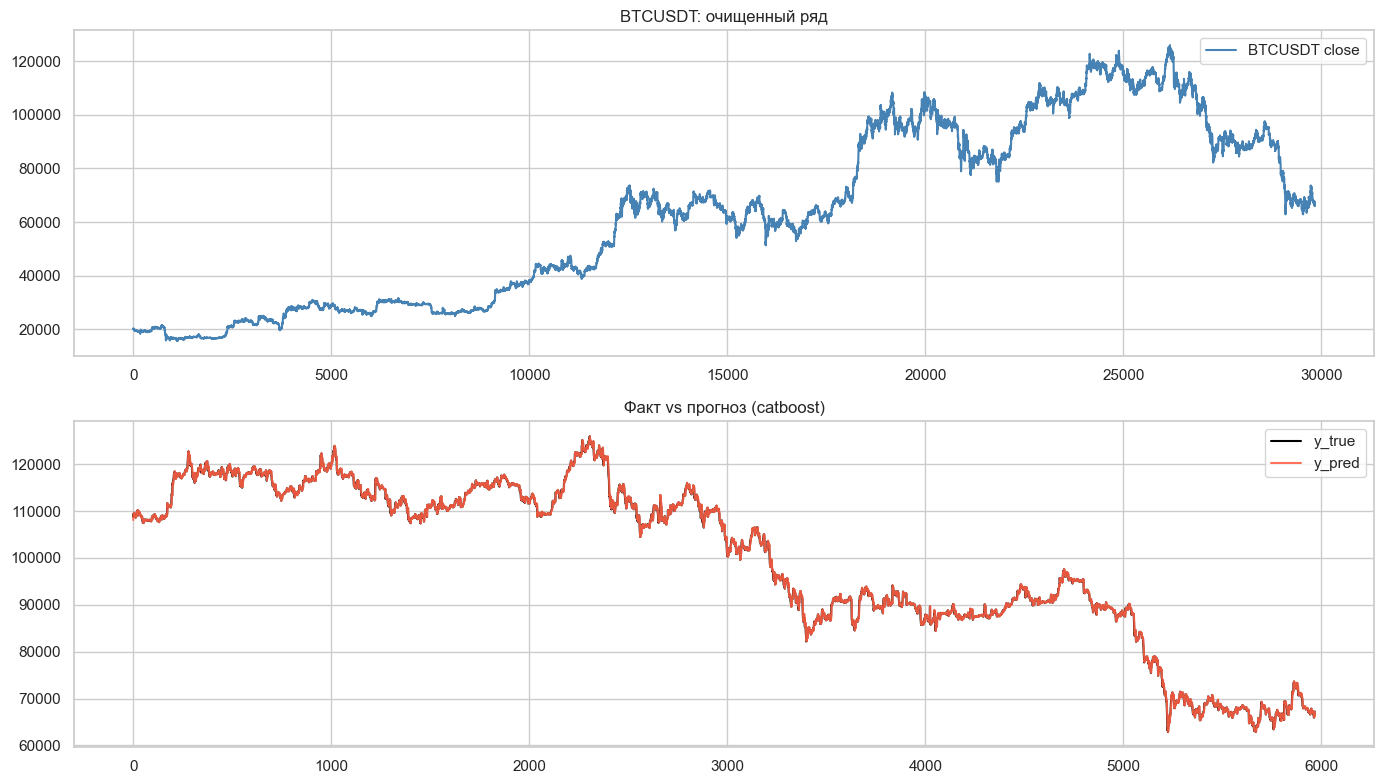

In [5]:
catboost_best_params, catboost_cv_df, model_metrics, pred_df, catboost_split_info = run_catboost_gridsearchcv_native_pipeline(
    full_series=full,
    param_grid=CATBOOST_PARAM_GRID,
    test_ratio=CONFIG.test_ratio,
    n_splits=CATBOOST_CV_SPLITS,
    scoring=CATBOOST_SCORING,
    use_cuda=CATBOOST_USE_CUDA,
    n_jobs=CATBOOST_GRID_N_JOBS,
    min_resource_points=CATBOOST_SEARCH_MIN_POINTS,
    max_resource_points=CATBOOST_SEARCH_MAX_POINTS,
    halving_factor=CATBOOST_HALVING_FACTOR,
    aggressive_elimination=True,
    time_weight=CATBOOST_TIME_WEIGHT,
)

ALL_RESULTS[RUN_MODEL] = {
    'metrics': model_metrics,
    'pred_df': pred_df.copy(),
    'symbol': RUN_SYMBOL,
}

TRAINED_MODELS[RUN_MODEL] = fit_catboost_inference_model(
    train,
    context_len=int(catboost_best_params['context_len']),
    depth=int(catboost_best_params['depth']),
    learning_rate=float(catboost_best_params['learning_rate']),
    iterations=int(catboost_best_params['iterations']),
    l2_leaf_reg=float(catboost_best_params.get('l2_leaf_reg', 3.0)),
    use_cuda=bool(catboost_best_params.get('use_cuda', CATBOOST_USE_CUDA)),
)

cv_preview_cols = [
    col for col in [
        'score',
        'score_std',
        'param_context_len',
        'param_depth',
        'param_learning_rate',
        'param_iterations',
        'param_l2_leaf_reg',
        'iter',
        'rank_test_score',
    ] if col in catboost_cv_df.columns
]

print('CatBoost split info:', catboost_split_info)
print('CatBoost best params:', catboost_best_params)
print('CatBoost metrics:', model_metrics)
display(catboost_cv_df[cv_preview_cols].head(20) if cv_preview_cols else catboost_cv_df.head(20))
display(pred_df.head())
display(pred_df.tail())
plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

## 6) Rolling 24h benchmark на minute-данных

Переобучаем только CatBoost на 40 000 минут train и проверяем 24-часовой горизонт на 10 последовательных окнах.

In [ ]:
import time

from typing import Any



from tqdm import tqdm



if not ROLLING_BENCHMARK_ENABLED:

    print('Rolling benchmark disabled (ROLLING_BENCHMARK_ENABLED=False).')

else:

    def _prepare_minute_backtest_df(df: pd.DataFrame) -> pd.DataFrame:

        out = df.copy()

        out['timestamp'] = pd.to_datetime(out['timestamp'], errors='coerce', utc=True)

        out['close'] = pd.to_numeric(out['close'], errors='coerce')

        out = out.dropna(subset=['timestamp', 'close'])

        out = out[out['close'] > 0].copy()

        out = out.sort_values('timestamp').drop_duplicates(subset=['timestamp'], keep='last').reset_index(drop=True)

        return out[['timestamp', 'close']]



    def _fit_benchmark_model(train_series: pd.Series) -> dict[str, Any]:

        return fit_catboost_inference_model(

            train_series,

            context_len=int(catboost_best_params['context_len']),

            depth=int(catboost_best_params['depth']),

            learning_rate=float(catboost_best_params['learning_rate']),

            iterations=int(catboost_best_params['iterations']),

            l2_leaf_reg=float(catboost_best_params.get('l2_leaf_reg', 3.0)),

            use_cuda=bool(catboost_best_params.get('use_cuda', CATBOOST_USE_CUDA)) and not BENCHMARK_FORCE_CPU,

        )



    total_required_points = BENCHMARK_TRAIN_MINUTES + BENCHMARK_WINDOWS * BENCHMARK_TEST_MINUTES

    benchmark_history_bars = max(CONFIG.bars, total_required_points + BENCHMARK_FETCH_BUFFER)

    benchmark_config = DataConfig(

        base_url=CONFIG.base_url,

        interval=BENCHMARK_INTERVAL,

        bars=benchmark_history_bars,

        target_col=CONFIG.target_col,

        date_col=CONFIG.date_col,

        test_ratio=CONFIG.test_ratio,

    )



    try:

        _, benchmark_snapshot = sync_market_data_to_sqlite(

            symbol=RUN_SYMBOL,

            config=benchmark_config,

            db_path=SQLITE_DB_PATH,

            history_bars=benchmark_history_bars,

            fetch_snapshot=True,

        )

        if benchmark_snapshot is not None:

            print(

                f'Realtime snapshot synced: ts={benchmark_snapshot["snapshot_ts"]} | '

                f'last={benchmark_snapshot["last_price"]} | bid={benchmark_snapshot["bid_price"]} | ask={benchmark_snapshot["ask_price"]}'

            )

    except Exception as ex:

        print(f'Rolling benchmark sync warning: {ex}. Использую уже сохранённые данные из SQLite.')



    minute_raw = load_klines_from_sqlite(

        symbol=RUN_SYMBOL,

        interval=BENCHMARK_INTERVAL,

        db_path=SQLITE_DB_PATH,

        limit=benchmark_history_bars,

    )

    minute_df = _prepare_minute_backtest_df(minute_raw)

    if len(minute_df) < total_required_points:

        raise RuntimeError(

            f'Недостаточно minute-данных в SQLite после подготовки: {len(minute_df)} < {total_required_points}. '

            'Увеличь историю в базе или уменьши окна benchmark.'

        )

    minute_df = minute_df.iloc[-total_required_points:].reset_index(drop=True)

    minute_series = minute_df['close'].astype(float).reset_index(drop=True)



    print(

        f"Minute benchmark data from SQLite: rows={len(minute_df)} | "

        f"from={minute_df['timestamp'].iloc[0]} | to={minute_df['timestamp'].iloc[-1]}"

    )



    benchmark_rows = []

    benchmark_t0 = time.perf_counter()

    for window_idx in tqdm(range(BENCHMARK_WINDOWS), desc='CatBoost rolling benchmark', unit='window'):

        offset = window_idx * BENCHMARK_TEST_MINUTES

        train_start = offset

        train_end = train_start + BENCHMARK_TRAIN_MINUTES

        test_start = train_end

        test_end = test_start + BENCHMARK_TEST_MINUTES



        train_series = minute_series.iloc[train_start:train_end].reset_index(drop=True)

        test_series = minute_series.iloc[test_start:test_end].reset_index(drop=True)

        train_start_ts = minute_df['timestamp'].iloc[train_start]

        train_end_ts = minute_df['timestamp'].iloc[train_end - 1]

        test_start_ts = minute_df['timestamp'].iloc[test_start]

        test_end_ts = minute_df['timestamp'].iloc[test_end - 1]



        fit_t0 = time.perf_counter()

        try:

            model_obj = _fit_benchmark_model(train_series)

            fit_sec = float(time.perf_counter() - fit_t0)

            pred_t0 = time.perf_counter()

            metrics_dict, benchmark_pred_df = predict_catboost_inference(model_obj, train_series, test_series)

            predict_sec = float(time.perf_counter() - pred_t0)

            benchmark_rows.append({

                'symbol': RUN_SYMBOL,

                'window': int(window_idx + 1),

                'model': 'catboost',

                'train_start_ts': train_start_ts,

                'train_end_ts': train_end_ts,

                'test_start_ts': test_start_ts,

                'test_end_ts': test_end_ts,

                'train_points': int(len(train_series)),

                'test_points': int(len(test_series)),

                'MAE': float(metrics_dict['MAE']),

                'RMSE': float(metrics_dict['RMSE']),

                'MAPE': float(metrics_dict['MAPE']),

                'fit_sec': fit_sec,

                'predict_sec': predict_sec,

                'total_sec': fit_sec + predict_sec,

            })

        except Exception as ex:

            benchmark_rows.append({

                'symbol': RUN_SYMBOL,

                'window': int(window_idx + 1),

                'model': 'catboost',

                'train_start_ts': train_start_ts,

                'train_end_ts': train_end_ts,

                'test_start_ts': test_start_ts,

                'test_end_ts': test_end_ts,

                'train_points': int(len(train_series)),

                'test_points': int(len(test_series)),

                'MAE': float('nan'),

                'RMSE': float('nan'),

                'MAPE': float('nan'),

                'fit_sec': float('nan'),

                'predict_sec': float('nan'),

                'total_sec': float('nan'),

                'error': str(ex),

            })



    benchmark_wall_sec = float(time.perf_counter() - benchmark_t0)

    rolling_benchmark_df = pd.DataFrame(benchmark_rows)

    rolling_summary_df = (

        rolling_benchmark_df.groupby('model', as_index=False)

        .agg(

            windows=('window', 'nunique'),

            mean_MAE=('MAE', 'mean'),

            mean_RMSE=('RMSE', 'mean'),

            mean_MAPE=('MAPE', 'mean'),

            mean_fit_sec=('fit_sec', 'mean'),

            mean_predict_sec=('predict_sec', 'mean'),

            mean_total_sec=('total_sec', 'mean'),

        )

    )



    rolling_ts = pd.Timestamp.now(tz='UTC').strftime('%Y%m%d_%H%M%S')

    rolling_detail_path = OUTPUT_DIR / f"{RUN_SYMBOL}_catboost_sqlite_minute100k_detail_{rolling_ts}.csv"

    rolling_summary_path = OUTPUT_DIR / f"{RUN_SYMBOL}_catboost_sqlite_minute100k_summary_{rolling_ts}.csv"

    rolling_benchmark_df.to_csv(rolling_detail_path, index=False)

    rolling_summary_df.to_csv(rolling_summary_path, index=False)



    print(f'Rolling benchmark wall time: {benchmark_wall_sec:.2f} sec')

    print('Сохранено:')

    print(rolling_detail_path.resolve())

    print(rolling_summary_path.resolve())

    print('\nRolling benchmark detail:')

    display(rolling_benchmark_df)

    print('\nRolling benchmark summary:')

    display(rolling_summary_df)

Minute benchmark data: rows=54400 | from=2026-01-30 09:25:00+00:00 | to=2026-03-09 04:04:00+00:00


CatBoost rolling benchmark: 100%|██████████| 10/10 [00:29<00:00,  2.91s/window]

Rolling benchmark wall time: 29.09 sec
Сохранено:
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_catboost_minute40000_24h10_detail_20260309_041320.csv
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_catboost_minute40000_24h10_summary_20260309_041320.csv

Rolling benchmark detail:


,symbol,window,model,train_start_ts,train_end_ts,test_start_ts,test_end_ts,train_points,test_points,MAE,RMSE,MAPE,fit_sec,predict_sec,total_sec
0,BTCUSDT,1,catboost,2026-01-30 09:25:00+00:00,2026-02-27 04:04:00+00:00,2026-02-27 04:05:00+00:00,2026-02-28 04:04:00+00:00,40000,1440,33.139451,48.178280,0.050004,3.921994,1.004089,4.926082
1,BTCUSDT,2,catboost,2026-01-31 09:25:00+00:00,2026-02-28 04:04:00+00:00,2026-02-28 04:05:00+00:00,2026-03-01 04:04:00+00:00,40000,1440,46.209241,67.518273,0.070622,4.831717,0.967796,5.799513
2,BTCUSDT,3,catboost,2026-02-01 09:25:00+00:00,2026-03-01 04:04:00+00:00,2026-03-01 04:05:00+00:00,2026-03-02 04:04:00+00:00,40000,1440,40.272581,60.790141,0.060676,1.302929,0.980113,2.283042
3,BTCUSDT,4,catboost,2026-02-02 09:25:00+00:00,2026-03-02 04:04:00+00:00,2026-03-02 04:05:00+00:00,2026-03-03 04:04:00+00:00,40000,1440,45.572808,64.058999,0.067216,1.318716,0.979611,2.298328
4,BTCUSDT,5,catboost,2026-02-03 09:25:00+00:00,2026-03-03 04:04:00+00:00,2026-03-03 04:05:00+00:00,2026-03-04 04:04:00+00:00,40000,1440,47.883684,65.177008,0.070625,1.297266,0.976207,2.273473
5,BTCUSDT,6,catboost,2026-02-04 09:25:00+00:00,2026-03-04 04:04:00+00:00,2026-03-04 04:05:00+00:00,2026-03-05 04:04:00+00:00,40000,1440,50.198473,70.541891,0.070054,1.297755,0.973308,2.271063
6,BTCUSDT,7,catboost,2026-02-05 09:25:00+00:00,2026-03-05 04:04:00+00:00,2026-03-05 04:05:00+00:00,2026-03-06 04:04:00+00:00,40000,1440,42.781543,59.546630,0.059592,1.315999,0.980526,2.296525
7,BTCUSDT,8,catboost,2026-02-06 09:25:00+00:00,2026-03-06 04:04:00+00:00,2026-03-06 04:05:00+00:00,2026-03-07 04:04:00+00:00,40000,1440,35.137753,51.314236,0.050775,1.311863,0.975620,2.287483
8,BTCUSDT,9,catboost,2026-02-07 09:25:00+00:00,2026-03-07 04:04:00+00:00,2026-03-07 04:05:00+00:00,2026-03-08 04:04:00+00:00,40000,1440,22.213443,31.056550,0.032870,1.327326,0.985290,2.312616
9,BTCUSDT,10,catboost,2026-02-08 09:25:00+00:00,2026-03-08 04:04:00+00:00,2026-03-08 04:05:00+00:00,2026-03-09 04:04:00+00:00,40000,1440,34.351734,51.574838,0.051372,1.354602,0.969885,2.324488



Rolling benchmark summary:


,model,windows,mean_MAE,mean_RMSE,mean_MAPE,mean_fit_sec,mean_predict_sec,mean_total_sec
0,catboost,10,39.776071,56.975685,0.058381,1.928017,0.979244,2.907261
